# Profiling Examples: Function, Line, and Memory Profiling

This notebook demonstrates various profiling techniques to identify performance bottlenecks and memory usage in Python code.

## Overview

- **Function Profiling**: Measures time spent in each function
- **Line Profiling**: Measures time spent on each line of code
- **Memory Profiling**: Tracks memory usage over time

We'll use several tools:
- `cProfile` and `pstats` (built-in)
- `line_profiler` (requires installation)
- `memory_profiler` (requires installation)

## Setup: Install Required Packages

In [1]:
import cProfile
import pstats
import io
import numpy as np
import time
from memory_profiler import profile
import matplotlib.pyplot as plt

## Example Functions for Profiling

Let's create some example functions with different performance characteristics:

In [2]:
def fibonacci_recursive(n):
    """Inefficient recursive implementation of fibonacci."""
    if n <= 1:
        return n
    return fibonacci_recursive(n-1) + fibonacci_recursive(n-2)

def fibonacci_iterative(n):
    """Efficient iterative implementation of fibonacci."""
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

def matrix_operations():
    """Perform various matrix operations."""
    # Create large matrices
    size = 500
    A = np.random.rand(size, size)
    B = np.random.rand(size, size)
    
    # Matrix multiplication
    C = np.dot(A, B)
    
    # Matrix inversion
    A_inv = np.linalg.inv(A)
    
    # Eigenvalue computation
    eigenvalues = np.linalg.eigvals(C[:100, :100])  # Use smaller matrix for speed
    
    return C, A_inv, eigenvalues

def data_processing():
    """Simulate data processing with loops."""
    data = []
    for i in range(10000):
        # Inefficient list operations
        data.append(i ** 2)
    
    # Process data
    result = []
    for value in data:
        if value % 2 == 0:
            result.append(np.sqrt(value))
    
    return result

In [ ]:
def find_duplicates_inefficient(data_size=10000):
    """Secretly expensive: repeated list membership checks.
    
    Using 'in' operator on lists is O(n), making this O(n²) overall.
    This is a common pattern that looks innocent but scales poorly.
    """
    data = list(range(data_size)) + list(range(data_size // 2))  # Some duplicates
    np.random.shuffle(data)
    
    duplicates = []
    seen = []
    
    for item in data:
        if item in seen:  # O(n) operation on a list!
            if item not in duplicates:  # Another O(n) operation!
                duplicates.append(item)
        else:
            seen.append(item)
    
    return duplicates

def find_duplicates_efficient(data_size=10000):
    """Efficient version using set for O(1) lookups.
    
    Using sets for membership testing is O(1), making this O(n) overall.
    """
    data = list(range(data_size)) + list(range(data_size // 2))
    np.random.shuffle(data)
    
    duplicates = set()
    seen = set()
    
    for item in data:
        if item in seen:  # O(1) operation on a set!
            duplicates.add(item)
        else:
            seen.add(item)
    
    return list(duplicates)

def process_json_files(num_files=100):
    """I/O bound: reading and parsing JSON files one at a time.
    
    The performance bottleneck here isn't obvious - it's the
    repeated file open/close operations and JSON parsing.
    """
    import json
    import tempfile
    import os
    
    # Create temporary directory and files
    temp_dir = tempfile.mkdtemp()
    
    # Write test data
    for i in range(num_files):
        data = {"id": i, "values": list(range(100)), "metadata": {"count": 100}}
        filepath = os.path.join(temp_dir, f"data_{i}.json")
        with open(filepath, "w") as f:
            json.dump(data, f)
    
    # Read files one by one (inefficient I/O pattern)
    results = []
    for i in range(num_files):
        filepath = os.path.join(temp_dir, f"data_{i}.json")
        with open(filepath, "r") as f:
            data = json.load(f)
            results.append(sum(data["values"]))
    
    # Cleanup
    for i in range(num_files):
        os.remove(os.path.join(temp_dir, f"data_{i}.json"))
    os.rmdir(temp_dir)
    
    return results

### Subtle Performance Issues

The following examples demonstrate performance bottlenecks that aren't immediately obvious:

1. **List vs Set**: Using `in` operator on lists is O(n), but on sets it's O(1) - makes a huge difference in loops!
2. **I/O Operations**: File operations often dominate execution time but aren't obvious from the code

## 1. Function Profiling with cProfile

`cProfile` is a built-in Python profiler that measures how much time is spent in each function.

In [3]:
def run_function_profiling():
    """Example function that calls other functions."""
    # Test fibonacci implementations
    result1 = fibonacci_recursive(20)
    result2 = fibonacci_iterative(20)
    
    # Run matrix operations
    matrix_results = matrix_operations()
    
    # Run data processing
    processed_data = data_processing()
    
    return result1, result2, matrix_results, processed_data

# Profile the function
profiler = cProfile.Profile()
profiler.enable()

# Run the function
results = run_function_profiling()

profiler.disable()

# Display results
s = io.StringIO()
ps = pstats.Stats(profiler, stream=s).sort_stats('cumulative')
ps.print_stats(20)  # Show top 20 functions
print(s.getvalue())

         39601 function calls (17592 primitive calls) in 0.035 seconds

   Ordered by: cumulative time
   List reduced from 304 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    0.035    0.017 /Users/poldrack/Dropbox/code/BetterCodeBetterScience/bettercode/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3665(run_code)
      6/2    0.000    0.000    0.035    0.017 {built-in method builtins.exec}
        1    0.000    0.000    0.033    0.033 /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_95947/424478045.py:1(run_function_profiling)
        1    0.002    0.002    0.028    0.028 /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_95947/1219497000.py:16(matrix_operations)
        1    0.000    0.000    0.019    0.019 /Users/poldrack/Dropbox/code/BetterCodeBetterScience/bettercode/.venv/lib/python3.13/site-packages/numpy/__init__.py:707(__getattr__)
     12/1    0.000   

### Understanding cProfile Output

- **ncalls**: Number of calls
- **tottime**: Total time spent in the function (excluding subfunctions)
- **percall**: tottime / ncalls
- **cumtime**: Cumulative time (including subfunctions)
- **percall**: cumtime / ncalls

### Alternative: Using the @profile decorator style with cProfile

In [4]:
# Compare recursive vs iterative fibonacci
print("Profiling recursive fibonacci:")
profiler = cProfile.Profile()
profiler.enable()
result = fibonacci_recursive(25)
profiler.disable()

s = io.StringIO()
ps = pstats.Stats(profiler, stream=s).sort_stats('cumulative')
ps.print_stats(10)
print(s.getvalue())

print("\nProfiling iterative fibonacci:")
profiler = cProfile.Profile()
profiler.enable()
result = fibonacci_iterative(25)
profiler.disable()

s = io.StringIO()
ps = pstats.Stats(profiler, stream=s).sort_stats('cumulative')
ps.print_stats(10)
print(s.getvalue())

Profiling recursive fibonacci:
         242988 function calls (192 primitive calls) in 0.024 seconds

   Ordered by: cumulative time
   List reduced from 71 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    0.019    0.009 /Users/poldrack/Dropbox/code/BetterCodeBetterScience/bettercode/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3665(run_code)
      3/2    0.000    0.000    0.019    0.009 {built-in method builtins.exec}
      2/1    0.000    0.000    0.019    0.019 /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_95947/2661685944.py:1(<module>)
 242794/1    0.024    0.000    0.015    0.015 /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_95947/1219497000.py:1(fibonacci_recursive)
        1    0.000    0.000    0.000    0.000 /Users/poldrack/Dropbox/code/BetterCodeBetterScience/bettercode/.venv/lib/python3.13/site-packages/zmq/sugar/attrsettr.py:43(__getattr__)


### Profiling List vs Set Membership (Common Performance Trap)

In [ ]:
# Compare list vs set for duplicate finding
print("Profiling duplicate finding with list (data_size=10000):")
profiler = cProfile.Profile()
profiler.enable()
result = find_duplicates_inefficient(10000)
profiler.disable()

s = io.StringIO()
ps = pstats.Stats(profiler, stream=s).sort_stats('cumulative')
ps.print_stats(10)
print(s.getvalue())
print(f"Found {len(result)} duplicates")

print("\nProfiling duplicate finding with set (data_size=10000):")
profiler = cProfile.Profile()
profiler.enable()
result = find_duplicates_efficient(10000)
profiler.disable()

s = io.StringIO()
ps = pstats.Stats(profiler, stream=s).sort_stats('cumulative')
ps.print_stats(10)
print(s.getvalue())
print(f"Found {len(result)} duplicates")

**Key Insight**: This is one of the most common performance mistakes in Python! The code looks identical except for using `list` vs `set`, but the performance difference is dramatic:

- **List membership (`item in list`)**: O(n) - must scan through the entire list
- **Set membership (`item in set`)**: O(1) - instant hash table lookup
- **In a loop**: This turns O(n²) behavior into O(n) - a massive improvement at scale

The profiler clearly shows the inefficient version spending most of its time checking membership, while the efficient version zips through. This demonstrates why:
1. **Data structure choice matters** - the wrong one can make your code orders of magnitude slower
2. **Simple operations compound** - an O(n) operation in an O(n) loop becomes O(n²)
3. **Profiling reveals the truth** - you might not guess this is the bottleneck from reading the code

### Profiling I/O-Bound Operations

In [ ]:
# Profile JSON file processing
print("Profiling JSON file I/O operations:")
profiler = cProfile.Profile()
profiler.enable()
result = process_json_files(50)
profiler.disable()

s = io.StringIO()
ps = pstats.Stats(profiler, stream=s).sort_stats('cumulative')
ps.print_stats(15)
print(s.getvalue())
print(f"\nProcessed {len(result)} files")
print("Notice the time spent in 'open', 'load', 'dump' and other I/O operations!")

**Key Insight**: With I/O-bound operations, the bottleneck isn't your Python code - it's the file system operations. The profiler reveals that most time is spent in `open()`, `json.load()`, and `json.dump()`. This is why:

1. Caching frequently accessed data helps
2. Batch processing is more efficient than processing one item at a time
3. In-memory operations are orders of magnitude faster than disk I/O

Even seemingly simple file operations can dominate your program's runtime!

## 2. Line Profiling with line_profiler

Line profiling shows time spent on each line of code, which is more granular than function profiling.

In [5]:
# Load the line_profiler extension
%load_ext line_profiler

In [6]:
# Profile matrix_operations line by line
%lprun -f matrix_operations matrix_operations()

Timer unit: 1e-09 s

Total time: 0.008942 s
File: /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_95947/1219497000.py
Function: matrix_operations at line 16

Line #      Hits         Time  Per Hit   % Time  Line Contents
    16                                           def matrix_operations():
    17                                               """Perform various matrix operations."""
    18                                               # Create large matrices
    19         1       1000.0   1000.0      0.0      size = 500
    20         1     648000.0 648000.0      7.2      A = np.random.rand(size, size)
    21         1     644000.0 644000.0      7.2      B = np.random.rand(size, size)
    22                                           
    23                                               # Matrix multiplication
    24         1     572000.0 572000.0      6.4      C = np.dot(A, B)
    25                                           
    26                                      

In [7]:
# Profile data_processing line by line
%lprun -f data_processing data_processing()

Timer unit: 1e-09 s

Total time: 0.013064 s
File: /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_95947/1219497000.py
Function: data_processing at line 34

Line #      Hits         Time  Per Hit   % Time  Line Contents
    34                                           def data_processing():
    35                                               """Simulate data processing with loops."""
    36         1          0.0      0.0      0.0      data = []
    37     10001    2187000.0    218.7     16.7      for i in range(10000):
    38                                                   # Inefficient list operations
    39     10000    2699000.0    269.9     20.7          data.append(i ** 2)
    40                                           
    41                                               # Process data
    42         1       1000.0   1000.0      0.0      result = []
    43     10001    2319000.0    231.9     17.8      for value in data:
    44     10000    2201000.0    220.1     1

### Line Profiling the Duplicate Finding Functions

Let's use line profiling to see exactly which lines consume the most time in our duplicate finding examples:

In [ ]:
# Profile the inefficient duplicate finding line by line
%lprun -f find_duplicates_inefficient find_duplicates_inefficient(list(range(5000)) + list(range(2500)))

In [ ]:
# Profile the efficient duplicate finding line by line
%lprun -f find_duplicates_efficient find_duplicates_efficient(list(range(5000)) + list(range(2500)))

**What to Look For in Line Profiler Output:**

When you run the cells above, the line profiler will show:

1. **Inefficient version (using lists)**:
   - The `if item in seen` line will show HIGH time and % time
   - The `if item not in duplicates` line will also be expensive
   - These lines are hot spots because list membership is O(n)
   
2. **Efficient version (using sets)**:
   - The `if item in seen` line will show MINIMAL time
   - Set operations are O(1) so they execute quickly
   - The bottleneck shifts to other operations (iteration, etc.)

This demonstrates exactly why choosing the right data structure matters - line profiling makes the performance difference crystal clear!

### Understanding line_profiler Output

- **Line #**: Line number in the source code
- **Hits**: Number of times the line was executed
- **Time**: Total time spent on that line (in timer units)
- **Per Hit**: Average time per execution
- **% Time**: Percentage of total time
- **Line Contents**: The actual source code

## 3. Memory Profiling

Memory profiling helps identify memory leaks and excessive memory usage.

In [8]:
# Load memory_profiler extension
%load_ext memory_profiler

In [9]:
@profile
def memory_intensive_function():
    """Function that uses significant memory."""
    # Create large arrays
    large_list = [i for i in range(1000000)]
    
    # Create numpy array
    large_array = np.zeros((1000, 1000))
    
    # Create another array
    another_array = np.random.rand(1000, 1000)
    
    # Perform operation
    result = large_array + another_array
    
    # Delete intermediate variables
    del large_list
    del large_array
    
    return result

In [10]:
# Profile memory usage line by line
%memit memory_intensive_function()

ERROR: Could not find file /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_95947/3215051154.py
peak memory: 188.50 MiB, increment: 41.70 MiB


In [11]:
# More detailed line-by-line memory profiling
%mprun -f memory_intensive_function memory_intensive_function()

ERROR: Could not find file /var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_95947/3215051154.py



Filename: /Users/poldrack/Dropbox/code/BetterCodeBetterScience/bettercode/.venv/lib/python3.13/site-packages/memory_profiler.py

Line #    Mem usage    Increment  Occurrences   Line Contents
  1185    188.5 MiB    188.5 MiB           1               @wraps(wrapped=func)
  1186                                                     def wrapper(*args, **kwargs):
  1187    188.5 MiB      0.0 MiB           1                   prof = get_prof()
  1188    212.3 MiB     23.8 MiB           1                   val = prof(func)(*args, **kwargs)
  1189    212.3 MiB      0.0 MiB           1                   show_results_bound(prof)
  1190    212.3 MiB      0.0 MiB           1                   return val

### Memory Usage Over Time

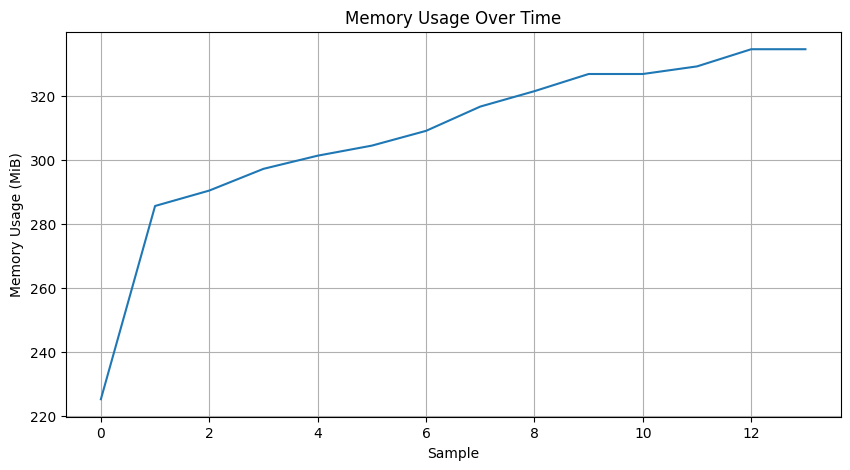

In [12]:
from memory_profiler import memory_usage

def growing_memory_function():
    """Function where memory grows over time."""
    data = []
    for i in range(100):
        # Append large arrays
        data.append(np.random.rand(1000, 100))
        time.sleep(0.01)  # Small delay to see progression
    return data

# Track memory usage over time
mem_usage = memory_usage((growing_memory_function, ), interval=0.1, include_children=True)

# Plot memory usage
plt.figure(figsize=(10, 5))
plt.plot(mem_usage)
plt.xlabel('Sample')
plt.ylabel('Memory Usage (MiB)')
plt.title('Memory Usage Over Time')
plt.grid(True)
plt.show()

### Surprising Memory Discovery: Pandas Categorical Data

One of the most surprising findings from memory profiling is how much memory repeated strings consume in pandas DataFrames. This is especially common in scientific data with categorical variables like experimental conditions, gender, country codes, etc.

The DataFrame **looks identical** but can use 10x or more memory depending on how the data is stored!

In [ ]:
import pandas as pd

# Simulate a typical scientific dataset with repeated categorical values
# This could be: experimental conditions, gender, country, diagnosis, etc.
n_rows = 100000

data = {
    'subject_id': range(n_rows),
    'condition': np.random.choice(['Control', 'Treatment_A', 'Treatment_B'], n_rows),
    'gender': np.random.choice(['Male', 'Female'], n_rows),
    'site': np.random.choice(['Site_Boston', 'Site_London', 'Site_Tokyo', 'Site_Sydney'], n_rows),
    'diagnosis': np.random.choice(['Healthy', 'Patient'], n_rows),
    'measurement': np.random.randn(n_rows)
}

# Create DataFrame with regular string columns (default)
df_strings = pd.DataFrame(data)

print("DataFrame with STRING columns:")
print(df_strings.dtypes)
print(f"\nMemory usage:\n{df_strings.memory_usage(deep=True)}")
print(f"\nTotal memory: {df_strings.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

In [ ]:
# Convert categorical columns to category dtype
df_categorical = df_strings.copy()
categorical_cols = ['condition', 'gender', 'site', 'diagnosis']

for col in categorical_cols:
    df_categorical[col] = df_categorical[col].astype('category')

print("DataFrame with CATEGORICAL columns:")
print(df_categorical.dtypes)
print(f"\nMemory usage:\n{df_categorical.memory_usage(deep=True)}")
print(f"\nTotal memory: {df_categorical.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

In [ ]:
# Compare memory savings
string_memory = df_strings.memory_usage(deep=True).sum()
categorical_memory = df_categorical.memory_usage(deep=True).sum()
reduction = (1 - categorical_memory / string_memory) * 100

print("=" * 60)
print("MEMORY COMPARISON")
print("=" * 60)
print(f"String columns:      {string_memory / 1024**2:.2f} MB")
print(f"Categorical columns: {categorical_memory / 1024**2:.2f} MB")
print(f"\nMemory reduction:    {reduction:.1f}%")
print(f"Memory saved:        {(string_memory - categorical_memory) / 1024**2:.2f} MB")
print("=" * 60)

# Verify the DataFrames are functionally identical
print("\nThe DataFrames look identical:")
print(df_strings.head())
print("\nBut use vastly different memory!")
print(f"\nData is still accessible the same way:")
print(f"df_strings['condition'].value_counts():\n{df_strings['condition'].value_counts()}")
print(f"\ndf_categorical['condition'].value_counts():\n{df_categorical['condition'].value_counts()}")

In [ ]:
# Visualize memory usage by column
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# String columns
mem_strings = df_strings.memory_usage(deep=True).drop('Index')
ax1.bar(range(len(mem_strings)), mem_strings / 1024**2)
ax1.set_xticks(range(len(mem_strings)))
ax1.set_xticklabels(mem_strings.index, rotation=45, ha='right')
ax1.set_ylabel('Memory (MB)')
ax1.set_title('Memory Usage: String Columns')
ax1.grid(axis='y', alpha=0.3)

# Categorical columns
mem_categorical = df_categorical.memory_usage(deep=True).drop('Index')
ax2.bar(range(len(mem_categorical)), mem_categorical / 1024**2, color='orange')
ax2.set_xticks(range(len(mem_categorical)))
ax2.set_xticklabels(mem_categorical.index, rotation=45, ha='right')
ax2.set_ylabel('Memory (MB)')
ax2.set_title('Memory Usage: Categorical Columns')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Why This Happens:**

1. **String storage**: Each occurrence of "Male", "Female", "Control", etc. stores a complete string object in memory
   - 100,000 rows with "Control" = 100,000 separate string objects
   
2. **Categorical storage**: Stores each unique value once, then uses integer codes to reference them
   - 100,000 rows with "Control" = 1 string + 100,000 integers (much smaller!)

**When to Use Categorical:**
- Low cardinality columns (few unique values, many repetitions)
- Text columns with repeated values: conditions, groups, categories, locations
- Can reduce memory by 10x or more for such columns
- Common in scientific datasets: experimental conditions, subject groups, sites, diagnoses

**Key Insight**: The DataFrame looks and behaves identically, but memory profiling reveals the huge difference. This is why profiling is essential - you'd never notice this without measuring!

**Pro tip**: When loading CSVs, specify categorical columns upfront:
```python
df = pd.read_csv('data.csv', dtype={'condition': 'category', 'gender': 'category'})
```

### Using Memory Profiler to Track DataFrame Creation

Let's use `memory_profiler` to see memory usage line-by-line during DataFrame creation and conversion:

In [ ]:
@profile
def create_string_dataframe(n_rows=100000):
    """Create DataFrame with string columns - watch memory grow!"""
    data = {
        'subject_id': range(n_rows),
        'condition': np.random.choice(['Control', 'Treatment_A', 'Treatment_B'], n_rows),
        'gender': np.random.choice(['Male', 'Female'], n_rows),
        'site': np.random.choice(['Site_Boston', 'Site_London', 'Site_Tokyo', 'Site_Sydney'], n_rows),
        'diagnosis': np.random.choice(['Healthy', 'Patient'], n_rows),
        'measurement': np.random.randn(n_rows)
    }
    
    df = pd.DataFrame(data)
    return df

@profile
def create_categorical_dataframe(n_rows=100000):
    """Create DataFrame and convert to categorical - watch memory decrease!"""
    data = {
        'subject_id': range(n_rows),
        'condition': np.random.choice(['Control', 'Treatment_A', 'Treatment_B'], n_rows),
        'gender': np.random.choice(['Male', 'Female'], n_rows),
        'site': np.random.choice(['Site_Boston', 'Site_London', 'Site_Tokyo', 'Site_Sydney'], n_rows),
        'diagnosis': np.random.choice(['Healthy', 'Patient'], n_rows),
        'measurement': np.random.randn(n_rows)
    }
    
    df = pd.DataFrame(data)
    
    # Convert to categorical - memory should drop here
    categorical_cols = ['condition', 'gender', 'site', 'diagnosis']
    for col in categorical_cols:
        df[col] = df[col].astype('category')
    
    return df

In [ ]:
# Profile string DataFrame creation line-by-line
%mprun -f create_string_dataframe create_string_dataframe(100000)

In [ ]:
# Profile categorical DataFrame creation line-by-line
%mprun -f create_categorical_dataframe create_categorical_dataframe(100000)

**What the Memory Profiler Shows:**

The `%mprun` (memory profiler) output reveals:

1. **String DataFrame**:
   - Memory increments significantly at `pd.DataFrame(data)` line
   - Each string column allocates separate memory for every string
   - Final memory usage is high

2. **Categorical DataFrame**:
   - Initial `pd.DataFrame(data)` creates strings (memory goes up)
   - Each `.astype('category')` line **reduces** memory significantly
   - You can see memory drop as each column is converted
   - Final memory usage is much lower

This external memory profiling confirms what pandas' `.memory_usage()` told us, but now you can see **exactly which lines** allocate and free memory. The `.astype('category')` conversion literally frees up memory by replacing string objects with integer codes!

**Key Difference**: 
- `df.memory_usage()` = static snapshot of memory used
- `memory_profiler` = dynamic view of memory changes line-by-line

## 4. Practical Example: Optimizing Code Based on Profiling

Let's profile inefficient code and then optimize it based on the results.

In [13]:
def inefficient_sum_of_squares(n):
    """Inefficient version using list comprehension and sum."""
    result = sum([i**2 for i in range(n)])
    return result

def efficient_sum_of_squares(n):
    """More efficient version using generator expression."""
    result = sum(i**2 for i in range(n))
    return result

def numpy_sum_of_squares(n):
    """NumPy vectorized version."""
    arr = np.arange(n)
    result = np.sum(arr**2)
    return result

In [14]:
# Profile all three versions
n = 1000000

print("Profiling inefficient version:")
%timeit inefficient_sum_of_squares(n)

print("\nProfiling efficient version:")
%timeit efficient_sum_of_squares(n)

print("\nProfiling NumPy version:")
%timeit numpy_sum_of_squares(n)

Profiling inefficient version:
33.7 ms ± 569 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

Profiling efficient version:
38.3 ms ± 150 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

Profiling NumPy version:
1.17 ms ± 64.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [15]:
# Memory comparison
print("Memory usage - inefficient version:")
%memit inefficient_sum_of_squares(n)

print("\nMemory usage - efficient version:")
%memit efficient_sum_of_squares(n)

print("\nMemory usage - NumPy version:")
%memit numpy_sum_of_squares(n)

Memory usage - inefficient version:
peak memory: 428.50 MiB, increment: 0.00 MiB

Memory usage - efficient version:
peak memory: 428.48 MiB, increment: 0.00 MiB

Memory usage - NumPy version:
peak memory: 428.48 MiB, increment: 0.00 MiB


## 5. Profiling Best Practices

### When to Use Each Tool:

1. **cProfile**: 
   - Quick overview of where time is spent
   - Identify which functions are bottlenecks
   - Low overhead, suitable for production code

2. **line_profiler**:
   - Detailed line-by-line analysis
   - After identifying slow functions with cProfile
   - Higher overhead, use during development

3. **memory_profiler**:
   - Track memory usage and leaks
   - Optimize memory-intensive applications
   - Significant overhead, use sparingly

### Tips:

- Profile representative workloads
- Profile multiple times to account for variability
- Focus on the biggest bottlenecks first (80/20 rule)
- Consider both time and space complexity
- Use vectorized operations (NumPy) when possible
- Avoid premature optimization - profile first!

## 6. Advanced: Profiling with Context Managers

In [16]:
class Timer:
    """Context manager for timing code blocks."""
    def __init__(self, name="Block"):
        self.name = name
    
    def __enter__(self):
        self.start = time.perf_counter()
        return self
    
    def __exit__(self, *args):
        self.end = time.perf_counter()
        self.elapsed = self.end - self.start
        print(f"{self.name} took {self.elapsed:.4f} seconds")

# Use the timer
with Timer("Matrix multiplication"):
    A = np.random.rand(1000, 1000)
    B = np.random.rand(1000, 1000)
    C = np.dot(A, B)

with Timer("List comprehension"):
    squares = [i**2 for i in range(1000000)]

with Timer("Generator expression"):
    squares_gen = list(i**2 for i in range(1000000))

Matrix multiplication took 0.0119 seconds
List comprehension took 0.0263 seconds
Generator expression took 0.0353 seconds


## Summary

This notebook demonstrated:

1. **Function profiling** with `cProfile` - identify which functions consume the most time
2. **Line profiling** with `line_profiler` - pinpoint exact lines causing bottlenecks
3. **Memory profiling** with `memory_profiler` - track memory usage and identify leaks
4. **Optimization workflow** - profile, identify bottlenecks, optimize, and verify improvements
5. **Best practices** - when and how to use each profiling tool

Remember: "Premature optimization is the root of all evil" - always profile before optimizing!